In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_csv('../data/users.csv')
print('Total records:', len(df))
df.head()

Total records: 13


,age,gender,total_income,utilities,entertainment,school_fees,shopping,healthcare
0,30,Female,6000.0,200.0,0.0,0.0,350.0,120.0
1,30,Female,6000.0,200.0,0.0,0.0,350.0,120.0
2,24,Male,770.0,50.0,70.0,100.0,50.0,0.0
3,22,Male,2500.0,80.0,200.0,500.0,100.0,50.0
4,25,Female,3200.0,120.0,150.0,400.0,300.0,80.0


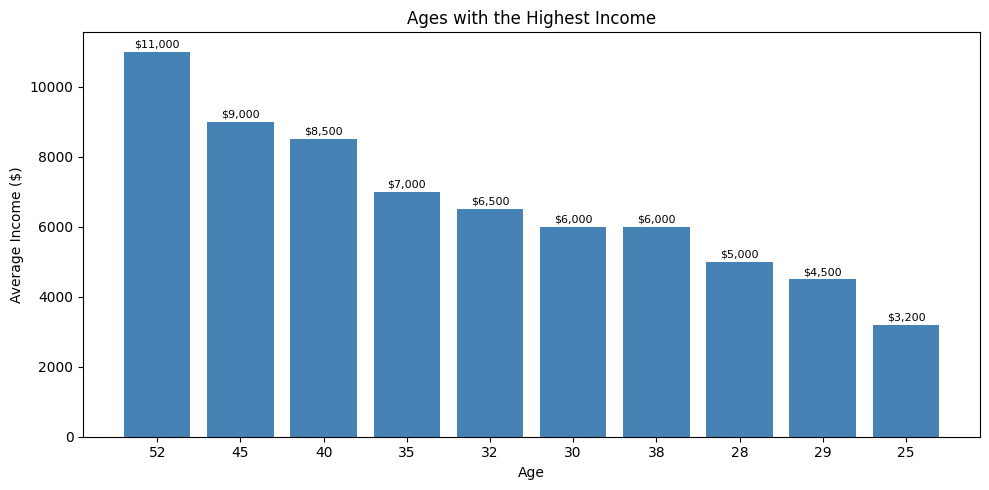

In [2]:
# Chart 1 - ages with the highest income
income_by_age = df.groupby('age')['total_income'].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(income_by_age.index.astype(str), income_by_age.values, color='steelblue')

ax.set_title('Ages with the Highest Income')
ax.set_xlabel('Age')
ax.set_ylabel('Average Income ($)')

for bar in bars:
    h = bar.get_height()
    ax.annotate(f'${h:,.0f}', xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

os.makedirs('charts', exist_ok=True)
plt.tight_layout()
plt.savefig('charts/income_by_age.png', dpi=150)
plt.show()

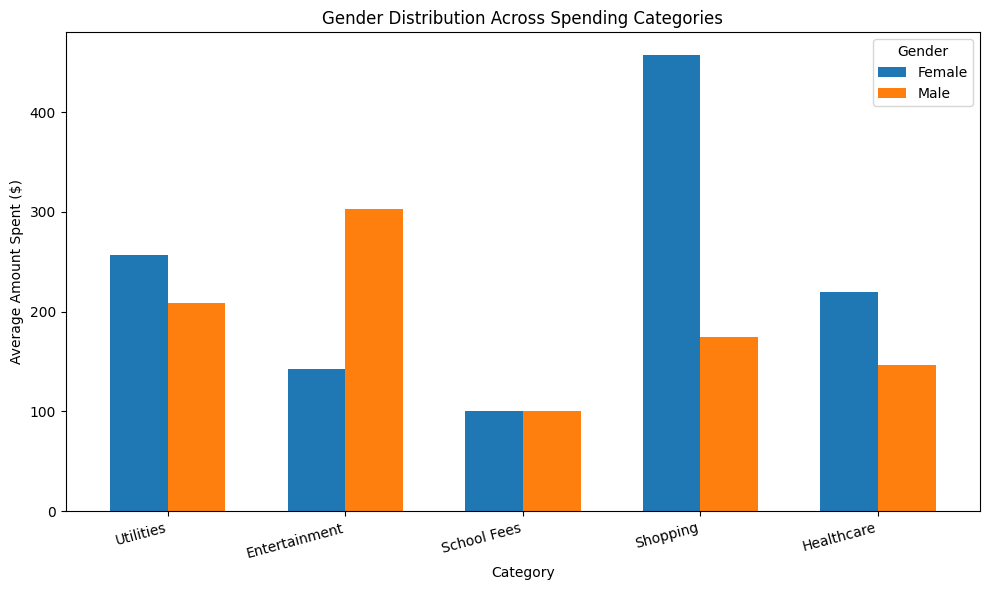

In [3]:
# Chart 2 - gender distribution across spending categories
categories = ['utilities', 'entertainment', 'school_fees', 'shopping', 'healthcare']
labels = ['Utilities', 'Entertainment', 'School Fees', 'Shopping', 'Healthcare']

gender_spending = df.groupby('gender')[categories].mean()

fig, ax = plt.subplots(figsize=(10, 6))
gender_spending.T.plot(kind='bar', ax=ax, width=0.65)

ax.set_title('Gender Distribution Across Spending Categories')
ax.set_xlabel('Category')
ax.set_ylabel('Average Amount Spent ($)')
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.legend(title='Gender')

plt.tight_layout()
plt.savefig('charts/gender_spending.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Summary stats
df[['age', 'total_income'] + categories].describe().round(2)

,age,total_income,utilities,entertainment,school_fees,shopping,healthcare
count,13.00,13.00,13.00,13.00,13.00,13.00,13.00
mean,33.08,5843.85,234.62,216.92,100.00,326.92,186.15
std,8.70,2767.01,126.99,152.94,177.95,189.97,162.41
min,22.00,770.00,50.00,0.00,0.00,50.00,0.00
25%,28.00,4500.00,180.00,100.00,0.00,200.00,100.00
50%,30.00,6000.00,200.00,200.00,0.00,300.00,120.00
75%,38.00,7000.00,300.00,300.00,100.00,400.00,200.00
max,52.00,11000.00,500.00,500.00,500.00,700.00,600.00
